In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('superstore_sales.csv')
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12/6/2016,16/6/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


check rows and columns

In [3]:
df.shape

(9994, 21)

identify data types

In [4]:
df.dtypes

row_id             int64
order_id          object
order_date        object
ship_date         object
ship_mode         object
customer_id       object
customer_name     object
segment           object
country           object
city              object
state             object
postal_code        int64
region            object
product_id        object
category          object
sub-category      object
product_name      object
sales            float64
quantity           int64
discount         float64
profit           float64
dtype: object

remove duplicates

In [5]:
df.duplicated().sum()

0

convert order and shipment dates to date time format 

In [6]:
df['order_date'] = pd.to_datetime(df['order_date'], format='%d/%m/%Y')
df['ship_date'] = pd.to_datetime(df['ship_date'], format='%d/%m/%Y')


numerical vs categorical columns

In [8]:
numerical = df.select_dtypes(include="number").columns
catogorical = df.select_dtypes(include="object").columns

numerical,catogorical

(Index(['row_id', 'postal_code', 'sales', 'quantity', 'discount', 'profit'], dtype='object'),
 Index(['order_id', 'ship_mode', 'customer_id', 'customer_name', 'segment',
        'country', 'city', 'state', 'region', 'product_id', 'category',
        'sub-category', 'product_name'],
       dtype='object'))

convert postal code to numeric

In [9]:
df['postal_code'] = pd.to_numeric(df['postal_code'])

detect outlines in scales

{'whiskers': [<matplotlib.lines.Line2D at 0x2772a283010>,
 'caps': [<matplotlib.lines.Line2D at 0x2772a290550>,
 'boxes': [<matplotlib.lines.Line2D at 0x2772a1f0350>],
 'medians': [<matplotlib.lines.Line2D at 0x2772a291b10>],
 'fliers': [<matplotlib.lines.Line2D at 0x2772a292710>],
 'means': []}

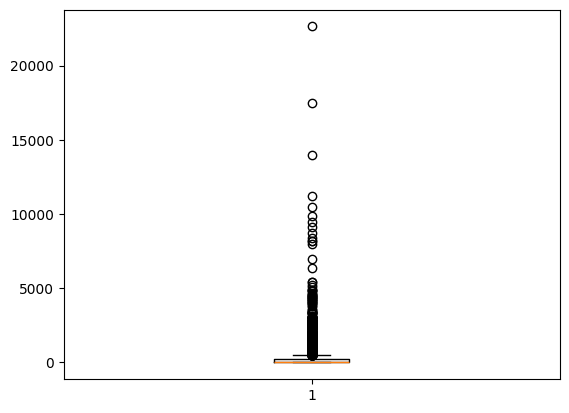

In [ ]:
plt.boxplot(df['sales'])


detect outlines in profit 

{'whiskers': [<matplotlib.lines.Line2D at 0x2772a3217d0>,
 'caps': [<matplotlib.lines.Line2D at 0x2772a323010>,
 'boxes': [<matplotlib.lines.Line2D at 0x2772a320b90>],
 'medians': [<matplotlib.lines.Line2D at 0x2772a32c850>],
 'fliers': [<matplotlib.lines.Line2D at 0x2772a32d450>],
 'means': []}

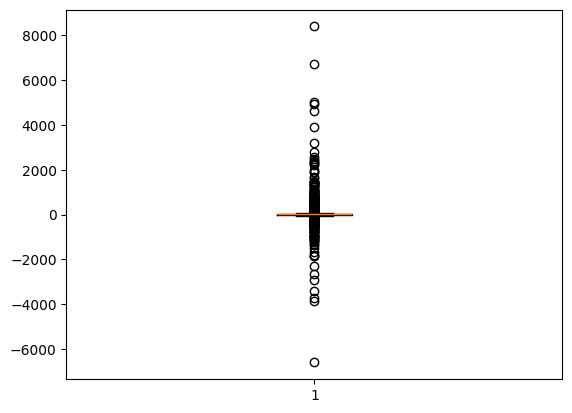

In [11]:
plt.boxplot(df['profit'])


drop row id and customer id which are useless

In [15]:
df=df.drop(columns = ['row_id'])
df=df.drop(columns = ['customer_id'])

clean customer name

In [22]:
df['customer_name'] = df['customer_name'].str.strip().str.title()

create a new cleaned version of this dataset

In [23]:
df.to_csv('cleaned_superstoreScales.csv')

In [24]:
newdf = pd.read_csv('cleaned_superstoreScales.csv')

plots --

share of total scales by category

<Axes: xlabel='category', ylabel='sales'>

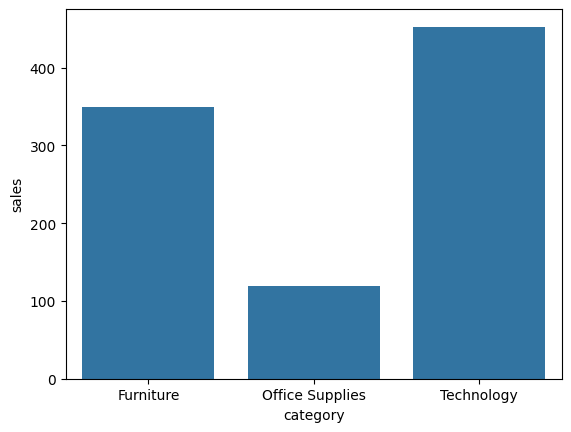

In [29]:
scales_by_category = newdf.groupby('category')['sales'].mean()
sns.barplot(scales_by_category)

scales trend over time(line plot)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,CA-2014-110422,2014-01-21,2014-01-23,Second Class,Tom Boeckenhauer,Consumer,United States,Miami,Florida,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200
